# LSTM Forecasting for CPI MoM Inflation

Clean LSTM version equivalent to the GRU notebook.

Model setup:
- Target: `cpi_mom_inflation`
- Inputs: exogenous variables only by default
- Window: 12 months
- Horizon: 1 month ahead
- Split: chronological train/validation/test
- Benchmark: Random Walk

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

plt.style.use("seaborn-v0_8-darkgrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step8_lstm")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
target_var = "cpi_mom_inflation"
exog_vars = [
    "broad_money", "ppi_qoq", "wti", "gold",
    "policy_rate", "VNINDEX", "NIKKEI225", "USDVND"
]

df_raw = pd.read_csv(
    os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv"),
    index_col=0,
    parse_dates=True
)

df_all = df_raw[[target_var] + exog_vars].copy().dropna()
print(f"Raw data shape: {df_all.shape}")
print(f"Period: {df_all.index.min().date()} to {df_all.index.max().date()}")

Raw data shape: (360, 9)
Period: 1995-01-01 to 2024-12-01


In [3]:
def classify_stationarity(series):
    s = pd.Series(series).dropna()
    adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    return "I(0)" if adf_p < 0.05 else "I(1)"

transformed, name_map = {}, {}

for col in df_all.columns:
    status = classify_stationarity(df_all[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_all[col]
    else:
        if col == "policy_rate" or (df_all[col] <= 0).any():
            new_col = f"diff_{col}"
            transformed[new_col] = df_all[col].diff()
        else:
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_all[col]).diff()

    name_map[col] = new_col

df = pd.DataFrame(transformed, index=df_all.index).dropna()

target_col = name_map[target_var]

# Option A: exogenous variables only, same as current GRU version
feature_cols = [c for c in df.columns if c != target_col]

# Option B: ARX-LSTM, use lagged inflation + exogenous variables
# feature_cols = list(df.columns)

print(f"Data shape: {df.shape}")
print(f"Target after transform: {target_col}")
print(f"Target included in features: {target_col in feature_cols}")
print(f"Feature columns: {feature_cols}")

Data shape: (359, 9)
Target after transform: cpi_mom_inflation
Target included in features: False
Feature columns: ['dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']


In [4]:
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []
    values_X = df[feature_cols].values
    values_y = df[target_col].values
    index = df.index

    for i in range(window, len(df) - horizon + 1):
        X.append(values_X[i-window:i])
        y.append(values_y[i + horizon - 1])
        dates.append(index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)

window = 12
horizon = 1

X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols,
    window=window,
    horizon=horizon
)

print("Supervised sequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Forecast horizon: {horizon} month ahead")

print("\nLeakage check")
print(f"X end date example: {df.index[window-1].date()}")
print(f"y date example:     {df.index[window].date()}")

Supervised sequence creation
X shape: (347, 12, 8)
y shape: (347,)
Forecast horizon: 1 month ahead

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01


In [5]:
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("Time-based split")
print(f"Train: X={X_train.shape}, y={y_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   X={X_val.shape}, y={y_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

Time-based split
Train: X=(242, 12, 8), y=(242,), 1996-02-01 to 2016-03-01
Val:   X=(35, 12, 8), y=(35,), 2016-04-01 to 2019-02-01
Test:  X=(70, 12, 8), y=(70,), 2019-03-01 to 2024-12-01


In [6]:
n_train, p, d = X_train.shape

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

print("Scaling completed")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling completed
X_train_scaled: (242, 12, 8)
X_val_scaled:   (35, 12, 8)
X_test_scaled:  (70, 12, 8)


In [7]:
def build_lstm(window, n_features, units=64, dropout=0.15, lr=0.001):
    model = Sequential([
        LSTM(
            units,
            input_shape=(window, n_features),
            return_sequences=True,
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout),

        LSTM(
            units // 2,
            return_sequences=False,
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout),

        Dense(
            32,
            activation="relu",
            kernel_regularizer=L1L2(l1=5e-6, l2=1e-5)
        ),
        Dropout(dropout * 0.5),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model

model = build_lstm(window=window, n_features=len(feature_cols))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,193 (125.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.6f}")
print(f"Final train loss: {history.history['loss'][-1]:.6f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.6f}")

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 1.0139 - mae: 0.7377 - val_loss: 0.2280 - val_mae: 0.3636 - learning_rate: 0.0010
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9625 - mae: 0.7211 - val_loss: 0.2196 - val_mae: 0.3594 - learning_rate: 0.0010
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9286 - mae: 0.7052 - val_loss: 0.2173 - val_mae: 0.3602 - learning_rate: 0.0010
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8771 - mae: 0.6878 - val_loss: 0.2116 - val_mae: 0.3613 - learning_rate: 0.0010
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8410 - mae: 0.6826 - val_loss: 0.2121 - val_mae: 0.3647 - learning_rate: 0.0010
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7669 - mae: 0.6515 - val_loss: 0.2198 - val_mae: 0.3739 - learning_rate: 0.0010
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7324 - mae: 0.6364 - val_loss: 0.2156 - val_mae: 0.3693 - learning_rate: 0.0010
Epoch 8/2

In [9]:
y_pred_scaled = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark
# Forecast y_t by y_{t-1}
y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

print("\nLSTM Test Results")
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")


LSTM Test Results
R²:                 -0.4526
RMSE:               0.567915
MAE:                0.466254
Random Walk RMSE:   0.564010
Random Walk MAE:    0.419571
Model / RW RMSE:    1.0069


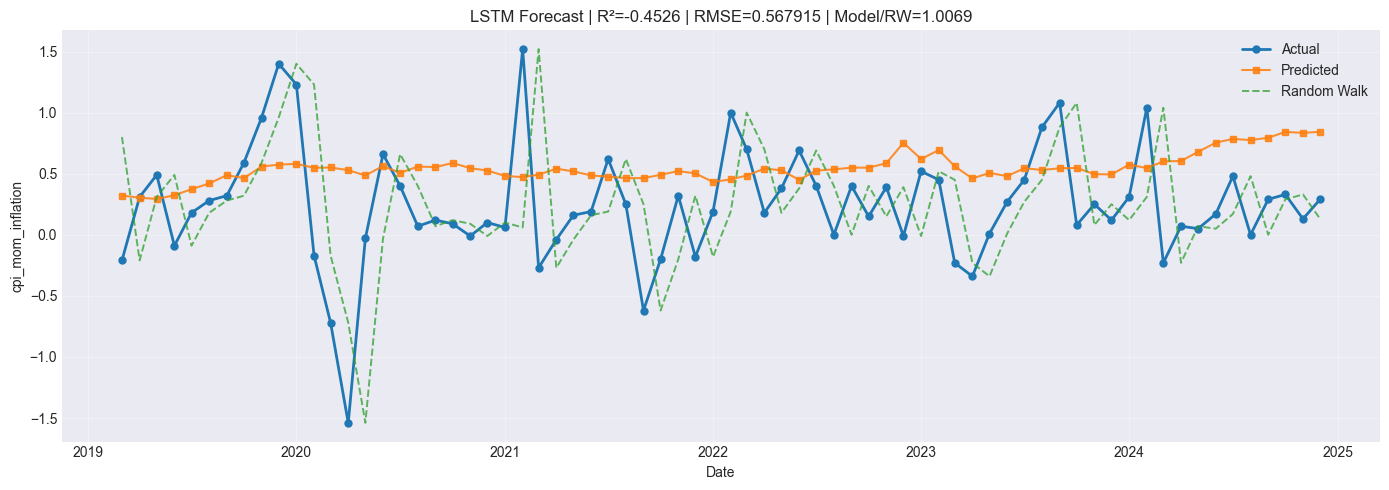

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.5, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.set_title(f"LSTM Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_forecast.png"), dpi=150)
plt.show()

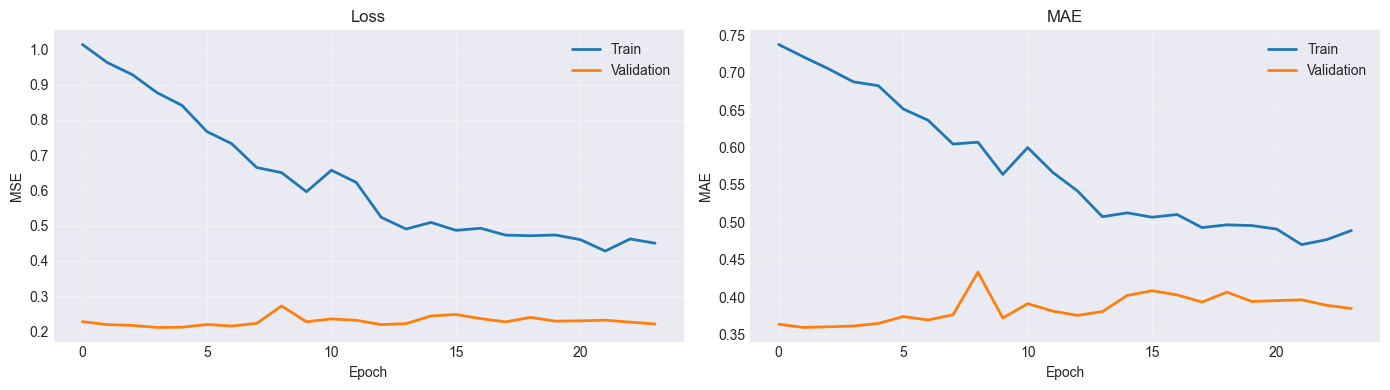

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history["loss"], label="Train", linewidth=2)
ax1.plot(history.history["val_loss"], label="Validation", linewidth=2)
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["mae"], label="Train", linewidth=2)
ax2.plot(history.history["val_mae"], label="Validation", linewidth=2)
ax2.set_title("MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_training.png"), dpi=150)
plt.show()

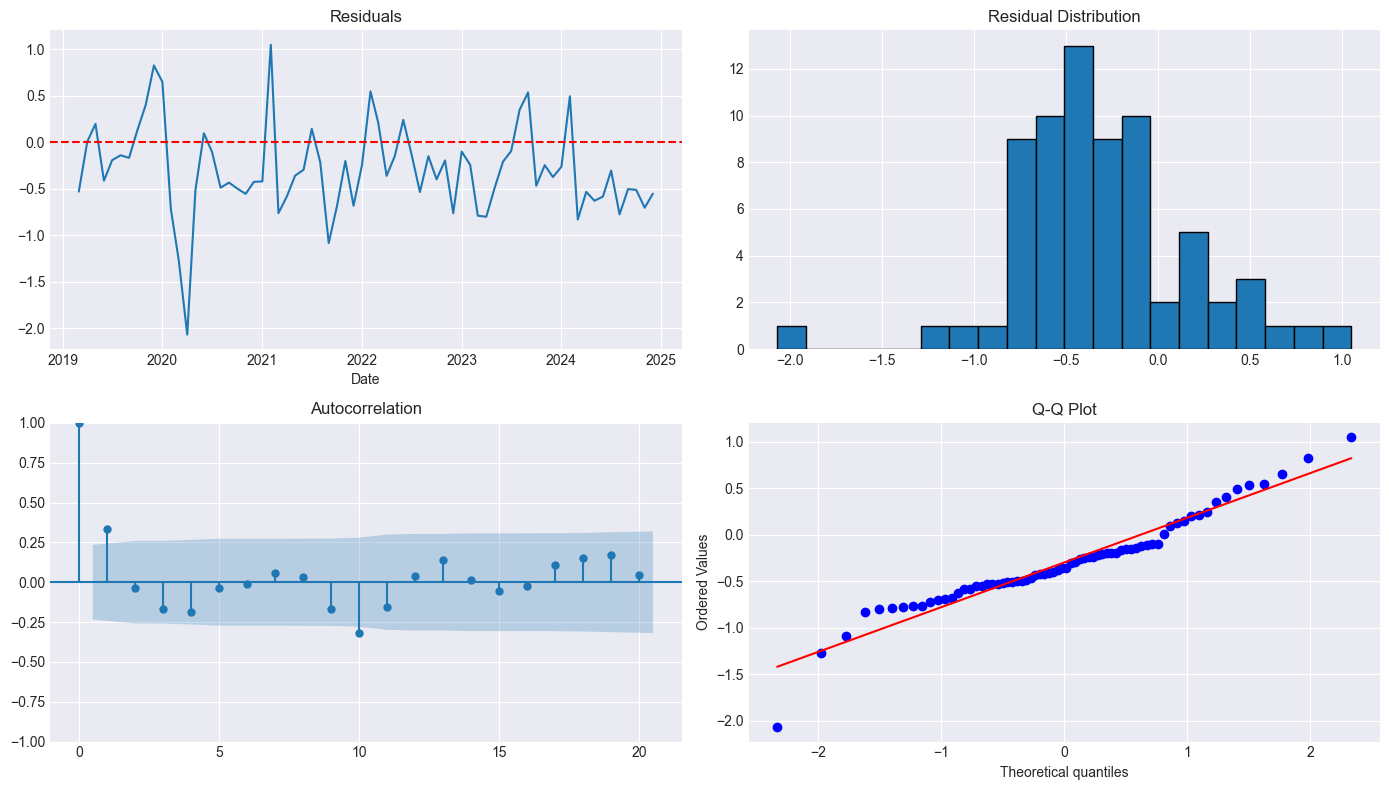

Residual diagnostics
Residual mean: -0.298338
Residual std:  0.483241
Jarque-Bera p-value: 0.001705


In [12]:
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lstm_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("Residual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

In [13]:
print("\n" + "="*80)
print("LSTM FORECASTING SUMMARY")
print("="*80)
print(f"Target: {target_col}")
print(f"Features: {len(feature_cols)}")
print(f"Target included in features: {target_col in feature_cols}")
print(f"Window: {window} months")
print(f"Horizon: {horizon} month ahead")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"Random Walk RMSE: {rmse_rw:.6f}")
print(f"Model / Random Walk RMSE: {vs_rw:.4f}")
print("="*80)


LSTM FORECASTING SUMMARY
Target: cpi_mom_inflation
Features: 8
Target included in features: False
Window: 12 months
Horizon: 1 month ahead
Train samples: 242
Validation samples: 35
Test samples: 70
R²: -0.4526
RMSE: 0.567915
MAE: 0.466254
Random Walk RMSE: 0.564010
Model / Random Walk RMSE: 1.0069


Improved ARX-LSTM setup
Target column: cpi_mom_inflation
Target included in features: True
Number of features: 9
Features: ['cpi_mom_inflation', 'dlog_broad_money', 'diff_ppi_qoq', 'dlog_wti', 'dlog_gold', 'diff_policy_rate', 'dlog_VNINDEX', 'dlog_NIKKEI225', 'dlog_USDVND']

Sequence creation
X shape: (347, 12, 9)
y shape: (347,)

Leakage check
X end date example: 1996-01-01
y date example:     1996-02-01
Correct if X end date is before y date.

Time split
Train: (242, 12, 9), 1996-02-01 to 2016-03-01
Val:   (35, 12, 9), 2016-04-01 to 2019-02-01
Test:  (70, 12, 9), 2019-03-01 to 2024-12-01


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 12, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 16)             │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,897 (34.75 KB)

 Trainable params: 8,897 (34.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.6084 - mae: 1.0115 - val_loss: 0.2454 - val_mae: 0.6080 - learning_rate: 5.0000e-04
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4955 - mae: 0.8900 - val_loss: 0.1666 - val_mae: 0.4829 - learning_rate: 5.0000e-04
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4298 - mae: 0.8023 - val_loss: 0.1479 - val_mae: 0.4541 - learning_rate: 5.0000e-04
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4257 - mae: 0.7921 - val_loss: 0.1303 - val_mae: 0.4288 - learning_rate: 5.0000e-04
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3825 - mae: 0.7433 - val_loss: 0.1212 - val_mae: 0.4049 - learning_rate: 5.0000e-04
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3690 - mae: 0.7052 - val_loss: 0.1236 - val_mae: 0.4018 - learning_rate: 5.0000e-04
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3450 - mae: 0.6861 - val_loss: 0.1231 - val_mae: 0.4063 - learning_r

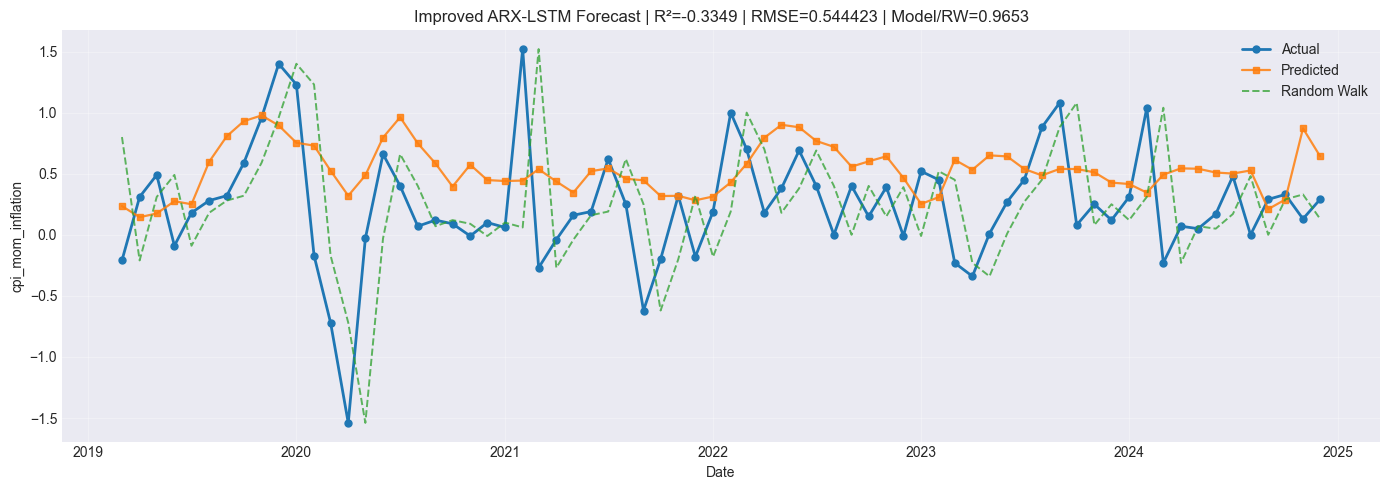

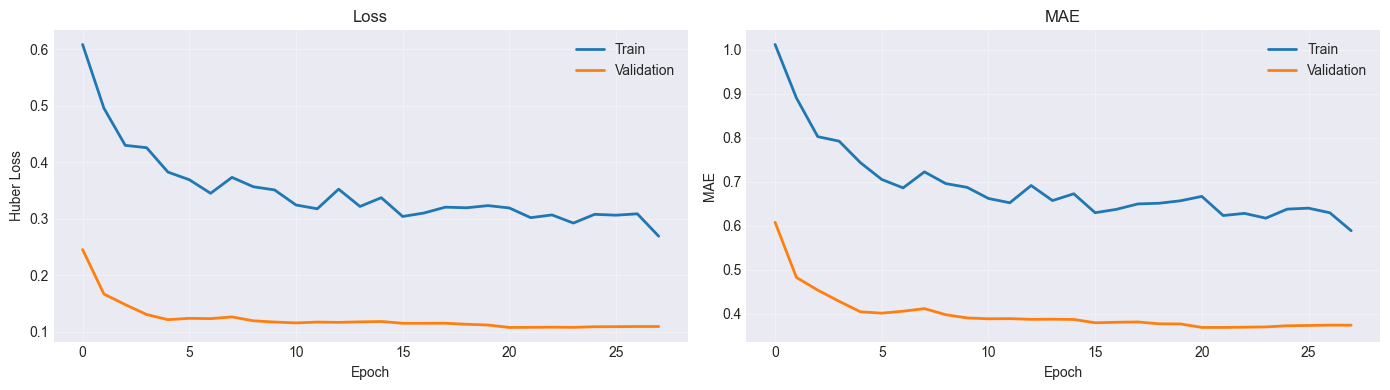

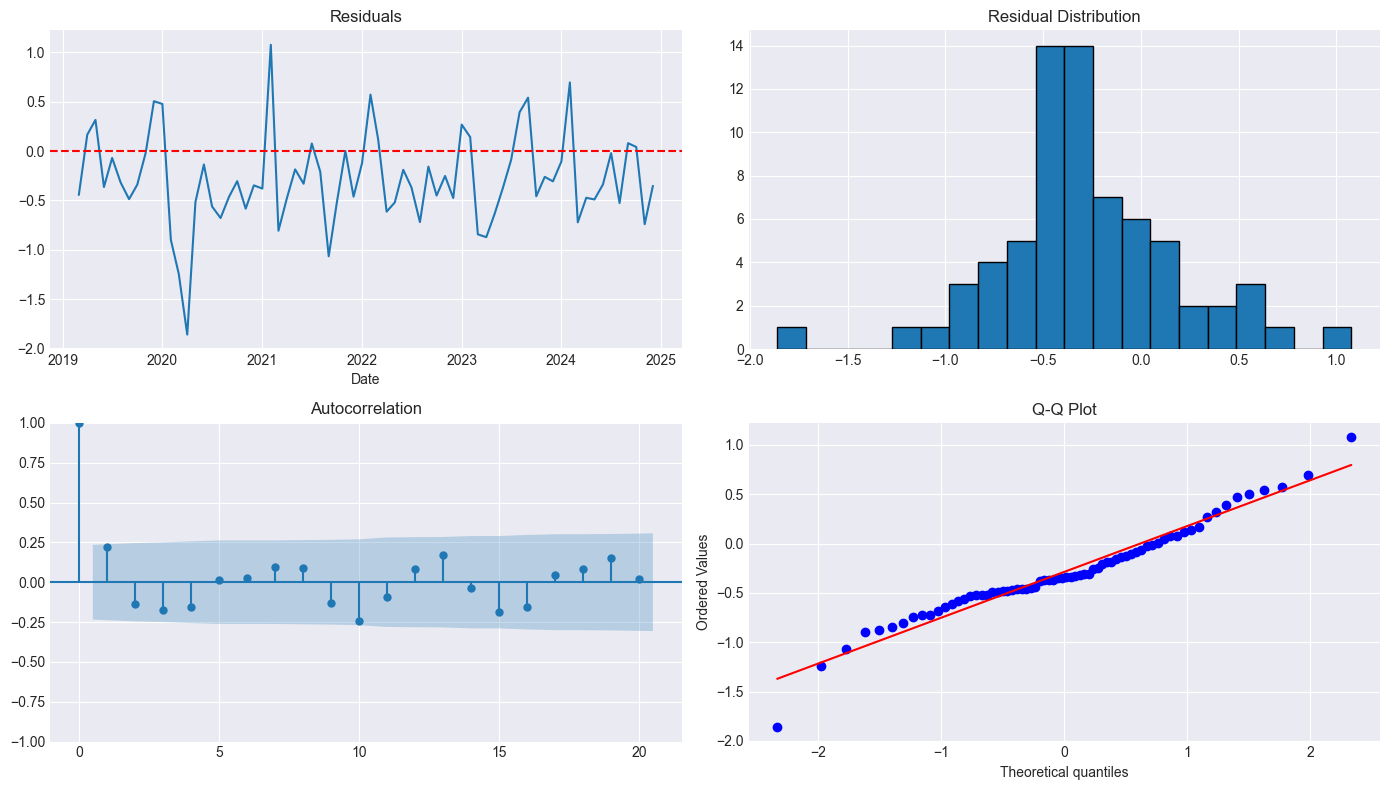


Residual diagnostics
Residual mean: -0.287071
Residual std:  0.462586
Jarque-Bera p-value: 0.025317


In [14]:
# ============================================================
# Improved ARX-LSTM: lagged target + exogenous variables
# ============================================================

import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber
from scipy.stats import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42
tf.keras.backend.clear_session()
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR_LSTM = os.path.join(os.getcwd(), "outputs", "step8_lstm_improved")
os.makedirs(OUTPUT_DIR_LSTM, exist_ok=True)

# -----------------------------
# 2. Configuration
# -----------------------------
window = 12
horizon = 1

# Include target as lagged autoregressive feature
# Safe because X uses only past observations
feature_cols_lstm = list(df.columns)

print("Improved ARX-LSTM setup")
print(f"Target column: {target_col}")
print(f"Target included in features: {target_col in feature_cols_lstm}")
print(f"Number of features: {len(feature_cols_lstm)}")
print(f"Features: {feature_cols_lstm}")

# -----------------------------
# 3. Create supervised sequences
# -----------------------------
def create_supervised_sequences(df, target_col, feature_cols, window=12, horizon=1):
    X, y, dates = [], [], []

    for i in range(window, len(df) - horizon + 1):
        X.append(df[feature_cols].iloc[i-window:i].values)
        y.append(df[target_col].iloc[i + horizon - 1])
        dates.append(df.index[i + horizon - 1])

    return np.array(X), np.array(y), pd.Index(dates)


X, y, y_dates = create_supervised_sequences(
    df=df,
    target_col=target_col,
    feature_cols=feature_cols_lstm,
    window=window,
    horizon=horizon
)

print("\nSequence creation")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nLeakage check")
print(f"X end date example: {df.index[window-1].date()}")
print(f"y date example:     {df.index[window].date()}")
print("Correct if X end date is before y date.")

# -----------------------------
# 4. Time-based split
# -----------------------------
n = len(X)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train, dates_train = X[:train_end], y[:train_end], y_dates[:train_end]
X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], y_dates[train_end:val_end]
X_test, y_test, dates_test = X[val_end:], y[val_end:], y_dates[val_end:]

print("\nTime split")
print(f"Train: {X_train.shape}, {dates_train[0].date()} to {dates_train[-1].date()}")
print(f"Val:   {X_val.shape}, {dates_val[0].date()} to {dates_val[-1].date()}")
print(f"Test:  {X_test.shape}, {dates_test[0].date()} to {dates_test[-1].date()}")

# -----------------------------
# 5. Scaling
# -----------------------------
n_train, p, d = X_train.shape

# RobustScaler helps with macro-financial outliers
x_scaler = RobustScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train.reshape(-1, d)).reshape(X_train.shape)
X_val_scaled = x_scaler.transform(X_val.reshape(-1, d)).reshape(X_val.shape)
X_test_scaled = x_scaler.transform(X_test.reshape(-1, d)).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

# -----------------------------
# 6. Build improved LSTM
# Smaller model to reduce overfitting
# -----------------------------
def build_improved_lstm(window, n_features, lr=0.0005):
    model = Sequential([
        LSTM(
            32,
            input_shape=(window, n_features),
            return_sequences=True
        ),
        LayerNormalization(),
        Dropout(0.20),

        LSTM(
            16,
            return_sequences=False
        ),
        LayerNormalization(),
        Dropout(0.15),

        Dense(16, activation="relu"),
        Dropout(0.10),

        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


model_lstm = build_improved_lstm(
    window=window,
    n_features=len(feature_cols_lstm),
    lr=0.0005
)

model_lstm.summary()

# -----------------------------
# 7. Train
# -----------------------------
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history_lstm = model_lstm.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=200,
    batch_size=8,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# 8. Test prediction
# -----------------------------
y_pred_scaled = model_lstm.predict(X_test_scaled, verbose=0).ravel()
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
y_test_actual = y_test.copy()

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

# Random Walk benchmark
y_rw = df[target_col].shift(1).reindex(dates_test).values
mask = ~np.isnan(y_rw)

rmse_rw = np.sqrt(mean_squared_error(y_test_actual[mask], y_rw[mask]))
mae_rw = mean_absolute_error(y_test_actual[mask], y_rw[mask])
vs_rw = rmse / rmse_rw if rmse_rw > 0 else np.nan

# Mean baseline, useful when R2 is negative
y_mean = np.repeat(np.mean(y_test_actual), len(y_test_actual))
rmse_mean = np.sqrt(mean_squared_error(y_test_actual, y_mean))
model_vs_mean = rmse / rmse_mean if rmse_mean > 0 else np.nan

print("\n" + "="*80)
print("IMPROVED ARX-LSTM TEST RESULTS")
print("="*80)
print(f"R²:                 {r2:.4f}")
print(f"RMSE:               {rmse:.6f}")
print(f"MAE:                {mae:.6f}")
print(f"Random Walk RMSE:   {rmse_rw:.6f}")
print(f"Random Walk MAE:    {mae_rw:.6f}")
print(f"Model / RW RMSE:    {vs_rw:.4f}")
print(f"Mean Baseline RMSE: {rmse_mean:.6f}")
print(f"Model / Mean RMSE:  {model_vs_mean:.4f}")
print("="*80)

if vs_rw < 1:
    print("Interpretation: ARX-LSTM beats Random Walk by RMSE.")
else:
    print("Interpretation: ARX-LSTM does not beat Random Walk by RMSE.")

# -----------------------------
# 9. Prediction diagnostics
# -----------------------------
print("\nPrediction diagnostics")
print(f"Actual mean: {np.mean(y_test_actual):.6f}")
print(f"Pred mean:   {np.mean(y_pred):.6f}")
print(f"Actual std:  {np.std(y_test_actual):.6f}")
print(f"Pred std:    {np.std(y_pred):.6f}")
print(f"Actual min:  {np.min(y_test_actual):.6f}")
print(f"Actual max:  {np.max(y_test_actual):.6f}")
print(f"Pred min:    {np.min(y_pred):.6f}")
print(f"Pred max:    {np.max(y_pred):.6f}")

# -----------------------------
# 10. Forecast plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates_test, y_test_actual, "o-", label="Actual", markersize=5, linewidth=2)
ax.plot(dates_test, y_pred, "s-", label="Predicted", markersize=4, linewidth=1.6, alpha=0.85)
ax.plot(dates_test[mask], y_rw[mask], "--", label="Random Walk", linewidth=1.4, alpha=0.75)

ax.set_title(f"Improved ARX-LSTM Forecast | R²={r2:.4f} | RMSE={rmse:.6f} | Model/RW={vs_rw:.4f}")
ax.set_xlabel("Date")
ax.set_ylabel(target_col)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_LSTM, "improved_arx_lstm_forecast.png"), dpi=150)
plt.show()

# -----------------------------
# 11. Training curve
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history["loss"], label="Train", linewidth=2)
axes[0].plot(history_lstm.history["val_loss"], label="Validation", linewidth=2)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Huber Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history["mae"], label="Train", linewidth=2)
axes[1].plot(history_lstm.history["val_mae"], label="Validation", linewidth=2)
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_LSTM, "improved_arx_lstm_training.png"), dpi=150)
plt.show()

# -----------------------------
# 12. Residual diagnostics
# -----------------------------
residuals = y_test_actual - y_pred
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(dates_test, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_LSTM, "improved_arx_lstm_residuals.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)

print("\nResidual diagnostics")
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")